# Radial Analyzer.ipynb
The workhorse notebook of a gas phase scattering beamtime. Loads in individual azimuthally averaged Jungfrau frames and all other smalldata parameters such as X-ray pulse energy, timetool edge position, etc. Can be used to look at static scattering patterns, filter out bad shots, build time-resolved difference signals, and much more.

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy

param_dict = {'spinewidth':2,
              'linewidth':4,
              'ticklength':6,
              'tickwidth':3,
              'ticklabelsize':20,
              'axislabelsize':20,
              'titlesize':25}
import matplotlib
def neaten_plot(neatenme, param_dict=param_dict):
    if isinstance(neatenme,matplotlib.figure.Figure):
        for ax in neatenme.axes:
            neaten_plot(ax)
        plt.tight_layout()
    elif isinstance(neatenme,matplotlib.axes.Axes):
        neatenme.tick_params(labelsize=param_dict['ticklabelsize'],length=param_dict['ticklength'],width=param_dict['tickwidth'])
        neatenme.xaxis.get_label().set_fontsize(param_dict['axislabelsize'])
        neatenme.yaxis.get_label().set_fontsize(param_dict['axislabelsize'])
        neatenme.title.set_fontsize(param_dict['titlesize'])
        for axis in ['top','bottom','left','right']:
            neatenme.spines[axis].set_linewidth(param_dict['spinewidth'])
        for line in neatenme.lines:
            line.set_linewidth(param_dict['linewidth'])
            
def plot_jungfrau(x,y,z,ax=None,shading='nearest',*args,**kwargs):
    if not ax:
        ax=plt.gca()
    for i in range(8):
        pcm = ax.pcolormesh(x[i],y[i],z[i],shading=shading,*args,**kwargs)
    return pcm

def createBinsFromCenters(centers):
    bins = []
    nc = centers.size
    for idx,c in enumerate(centers):
        if idx == 0:
            dc = np.abs( c - centers[idx+1])/2.
            bins.append(c-dc)
            bins.append(c+dc)
        elif idx == nc-1:
            dc = np.abs( c - centers[idx-1])/2.
            bins.append(c+dc)
        else:
            dc = np.abs( c - centers[idx+1])/2.
            bins.append(c+dc)
    return np.sort(np.array(bins))
            
def get_tree(f):
    """List the full tree of the h5 file"""
    def printname(name):  # needed because .visit needs callable
        print(name, type(f[name]))
    f.visit(printname)
    
def is_leaf(dataset):
    return isinstance(dataset,h5py.Dataset)

def get_leaves(f,saveto,verbose=False,keys=None):
    def return_leaf(name):
        if is_leaf(f[name]):
            if verbose:
                print(name,f[name][()].shape)
            if keys is None or name in keys:
                saveto[name] = f[name][()]
    f.visit(return_leaf)
    
def runNumToString(num):
    numstr = str(num)
    while len(numstr)<4:
        numstr = '0'+numstr
    return numstr

# Import data from .h5 file

In [25]:
keys_to_combine = ['tt/FLTPOS',
                   'tt/AMPL',
                   'tt/FLTPOSFWHM',
                   # 'scan/var0',
                   # 'scan/lxt_ttc',
                   # 'scan/lxt',
                   'ttRaw/tt_reference',
                   'ttRaw/tt_reference_pj',
                   'ttRaw/tt_sideband',
                   'ttRaw/tt_sideband_pj',
                   'ttRaw/tt_signal',
                   'ttRaw/tt_signal_pj',
                   # 'scan/lxt',
                   # 'epics/lxt',
                   # 'scan/varStep',
                   # 'scan/LAS:FS5:VIT:FS_TGT_TIME_DIAL',
                   # 'ipm_dg2/sum','ipm_dg2/peaks','ipm_dg2/xpos','ipm_dg2/ypos',
                   # 'ipm_dg3/sum',
                   'gas_detector/f_11_ENRC','gas_detector/f_12_ENRC','gas_detector/f_21_ENRC',
                   'gas_detector/f_22_ENRC',
                   'jungfrau4M/azav_azav',
                   # 'evr/code_183',
                   # 'evr/code_137',
                   'lightStatus/laser',
                   'lightStatus/xray',#'qadc0/full_area','qadc0/full_area',
                   # 'ttRawRefit/edge_locations',
                   # 'ttRaw/tt_reference',
                   # 'ttRaw/tt_signal',
                   # 'alvium_u1/laser_com','alvium_u1/laser_sum',#'alvium_u1/laser_pj0_data','alvium_u1/laser_pj1_data',
                   # 'ttRefit_LFH/ampl','ttRefit_LFH/edge_locations','ttRefit_LFH/normalized_data','ttRefit_LFH/slope',
                   'ttRefit_IG/edge_locations','ttRefit_IG/width','ttRefit_IG/height',
                   'dg2_traces'
                  ]


keys_to_sum = []
keys_to_check = [
                'UserDataCfg/jungfrau4M/azav__azav_q',
                'UserDataCfg/jungfrau4M/azav__azav_qbin',
                'UserDataCfg/jungfrau4M/azav__azav_qbins',
                'UserDataCfg/jungfrau4M/azav__azav_idxq',
                # 'UserDataCfg/jungfrau4M/x',
                # 'UserDataCfg/jungfrau4M/y',
                # 'UserDataCfg/jungfrau4M/z',
                # 'UserDataCfg/jungfrau4M/azav__azav_matrix_q',
                # 'UserDataCfg/jungfrau4M/azav__azav_matrix_phi',
                # 'UserDataCfg/jungfrau4M/cmask',
                # 'UserDataCfg/jungfrau4M/Full_thres__Full_thres_thresADU',
                # 'UserDataCfg/jungfrau4M/Full_thres__Full_thres_bound',
                # 'UserDataCfg/jungfrau4M/common_mode_pars','UserDataCfg/alvium_u1/cmask',
                ]
all_keys = keys_to_combine+keys_to_sum+keys_to_check
def combineRuns(runNumbers,folder,verbose=False,keys=all_keys):
    data_array = []
    experiment = folder.split('/')[6]
    for i,runNumber in enumerate(runNumbers):
        data = {}
        filename = f'{folder}{experiment}_Run{runNumToString(runNumber)}.h5'
        print(filename)
        with h5py.File(filename,'r') as f:
            get_leaves(f,data,verbose=verbose,keys=all_keys)
            if 'jungfrau4M/azav_azav' in all_keys:
                azav_run = data['jungfrau4M/azav_azav']
                if len(azav_run.shape)==3:
                    azav_run = np.nanmean(azav_run,axis=1)
                    data['jungfrau4M/azav_azav'] = azav_run
            data_array.append(data)
    print('loaded data')
    data_combined = {}
    for key in keys_to_combine:
        arr = np.squeeze(data_array[0][key])
        for data in data_array[1:]:
            arr = np.concatenate((arr,np.squeeze(data[key])),axis=0)
        data_combined[key] = arr
    run_indicator = np.array([])
    for i,runNumber in enumerate(runNumbers):
        run_indicator = np.concatenate((run_indicator,runNumber*np.ones_like(data_array[i]['lightStatus/xray'])))
    data_combined['run_indicator'] = run_indicator
    for key in keys_to_sum:
        arr = np.zeros_like(data_array[0][key])
        for data in data_array:
            arr += data[key]
        data_combined[key] = arr
    for key in keys_to_check:
        arr = data_array[0][key]
        for i,data in enumerate(data_array):
            if not np.array_equal(data[key],arr):
                print(f'Problem with key {key} in run {runNumbers[i]}')
        data_combined[key] = arr
    return data_combined

In [18]:
# import psana
# experiment = 'cxix1014323'
# runNumber = 49

# dsname = f'exp={experiment}:run={runNumber}'
# ds = psana.DataSource(dsname)
# dg2Det = psana.Detector('CXI-DG2-BMMON-WF')

# for i,evt in enumerate(ds.events()):
#     if not i%500:
#         print(i)
#     try:
#         traces = np.array(dg2Det(evt))[:8,::8]
#     except:
#         print('bad',i)

In [26]:
runNumbers = [90]

folder = '/sdf/data/lcls/ds/cxi/cxix1014323/hdf5/smalldata/'
# folder = '/sdf/data/lcls/ds/cxi/cxix1014323/scratch/igabalsk/ttRaw/'
folder = '/sdf/data/lcls/ds/cxi/cxil1038423/scratch/igabalsk/dg2/'
folder = '/sdf/data/lcls/ds/cxi/cxil1013521/scratch/igabalsk/dg2/'

data = combineRuns(runNumbers,folder=folder,verbose=False)
runNumbersRange = '[%d - %d]' % (min(runNumbers),max(runNumbers))

# ttpos = data['tt/FLTPOS']
# # ttpos = data['ttRawRefit/edge_locations']
# ttampl = data['tt/AMPL']
# ttfwhm = data['tt/FLTPOSFWHM']

ttpos = data['ttRefit_IG/edge_locations']
ttampl = data['ttRefit_IG/height']
ttfwhm = data['ttRefit_IG/width']

# ttpos = data['ttRefit_LFH/edge_locations']
# ttampl = data['ttRefit_LFH/ampl']
# ttfwhm = data['ttRefit_LFH/slope']

tt_reference = data['ttRaw/tt_reference']
tt_reference_pj = data['ttRaw/tt_reference_pj']
tt_sideband = data['ttRaw/tt_sideband']
tt_sideband_pj = data['ttRaw/tt_sideband_pj']
tt_signal = data['ttRaw/tt_signal']
tt_signal_pj = data['ttRaw/tt_signal_pj']

# scan = data['scan/var0']
# scan = data['scan/lxt_ttc']
# scan = data['scan/lxt']

q = data['UserDataCfg/jungfrau4M/azav__azav_q']
idxq = data['UserDataCfg/jungfrau4M/azav__azav_idxq'].reshape(8,512,1024)
qbin_size = np.bincount(idxq.flatten())
qbin = data['UserDataCfg/jungfrau4M/azav__azav_qbin']
qbins = data['UserDataCfg/jungfrau4M/azav__azav_qbins']
# x = data['UserDataCfg/jungfrau4M/x']
# y = data['UserDataCfg/jungfrau4M/y']
# z = data['UserDataCfg/jungfrau4M/z']
# matrix_q = data['UserDataCfg/jungfrau4M/azav__azav_matrix_q'].reshape(8,512,1024)
# matrix_phi = data['UserDataCfg/jungfrau4M/azav__azav_matrix_phi'].reshape(8,512,1024)

# dg2 = data['ipm_dg2/sum']
# dg2_peaks = data['ipm_dg2/peaks']
# dg2_xpos = data['ipm_dg2/xpos']
# dg2_ypos = data['ipm_dg2/ypos']
# dg3 = data['ipm_dg3/sum']

xray_energy11 = data['gas_detector/f_11_ENRC']
xray_energy12 = data['gas_detector/f_12_ENRC']
xray_energy21 = data['gas_detector/f_21_ENRC']
xray_energy22 = data['gas_detector/f_22_ENRC']
xray_energy = data['gas_detector/f_22_ENRC']

azav = np.squeeze(data['jungfrau4M/azav_azav'])
azav_xrays = azav*qbin_size

# laserOn = data['evr/code_183'].astype(bool)
# xrayOn = data['evr/code_137'].astype(bool)
laserOn = data['lightStatus/laser'].astype(bool)
xrayOn = data['lightStatus/xray'].astype(bool)

# jungfrau_sum = data['Sums/jungfrau4M_calib']
# jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']
# cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool)

run_indicator = data['run_indicator']

# tt_reference = data['ttRaw/tt_reference']
# tt_signal = data['ttRaw/tt_signal']
# tt_reference = (tt_reference.T/np.sum(tt_reference[:,600:],axis=1)).T
# tt_signal = (tt_signal.T/np.sum(tt_signal[:,600:],axis=1)).T
# index = np.arange(0,laserOn.size)
# ttRaw_signal = data['ttRaw/tt_signal']

# alvium_com = data['alvium_u1/laser_com']
# alvium_mask = data['UserDataCfg/alvium_u1/cmask']
# alvium_pj0 = data['alvium_u1/laser_pj0_data']
# alvium_pj1 = data['alvium_u1/laser_pj1_data']
# alvium_sum = data['alvium_u1/laser_sum']

print('stored data in arrays')
# detector_efficiency = np.load('detector_efficiency_15p3KeV.npy')
# detector_efficiency = np.interp(q,detector_efficiency[0],detector_efficiency[1])
# azav_corr = azav_xrays/detector_efficiency

# q = q[2:-1]
# azav_xrays = azav_xrays[:,2:-1]
# qbin_size = qbin_size[2:-1]

dg2_traces = data['dg2_traces']

dg2_traces = dg2_traces[:,:,:]
del data

/sdf/data/lcls/ds/cxi/cxil1013521/scratch/igabalsk/dg2/cxil1013521_Run0090.h5
loaded data
stored data in arrays


In [27]:
dg2_traces.shape
azav_xrays.shape

(21654, 67)

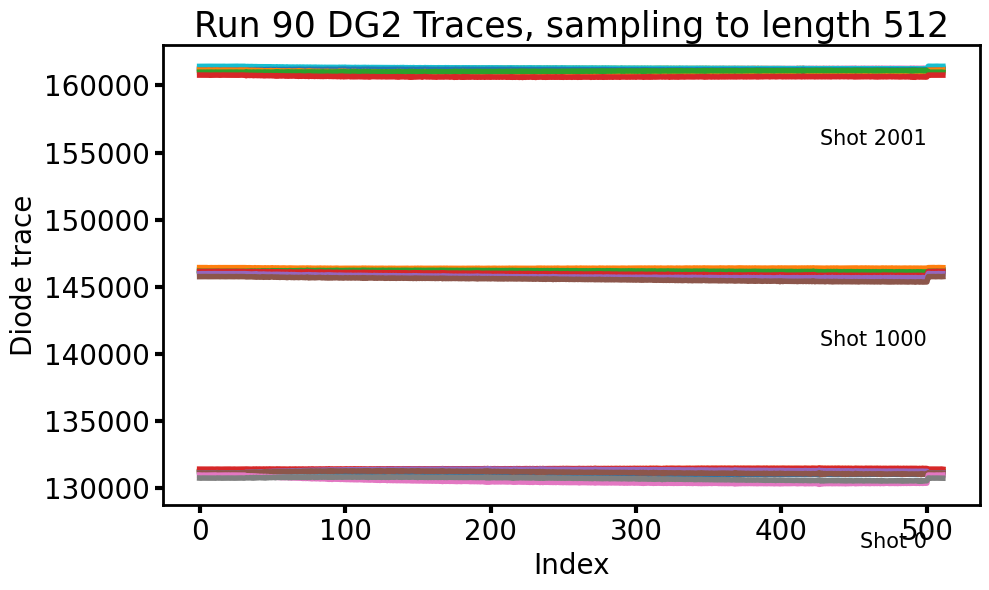

In [28]:
dg2_indices = [0,1000,2001]

plt.figure(figsize=(10,6))
# plt.subplot(121)
y_offset = 15000
for j, dg2_index in enumerate(dg2_indices):
    for i,trace in enumerate(dg2_traces[dg2_index]):
        plt.plot(trace+y_offset*j)
    plt.text(500,trace[-1]+y_offset*j-4000,f'Shot {dg2_index}',fontsize=15,ha='right',va='top')
plt.xlabel('Index')
plt.ylabel('Diode trace')
plt.title(f'Run {runNumbers[0]} DG2 Traces, sampling to length {dg2_traces.shape[-1]}')


# plt.subplot(122)
# for j, dg2_index in enumerate(dg2_indices):
#     plt.plot(q,azav_xrays[dg2_index]/qbin_size,label=f'Shot {dg2_index}')
# plt.xlabel('q')
# plt.ylabel('Azav')
# plt.title(f'Azav')
# plt.legend(fontsize=15)
neaten_plot(plt.gcf())


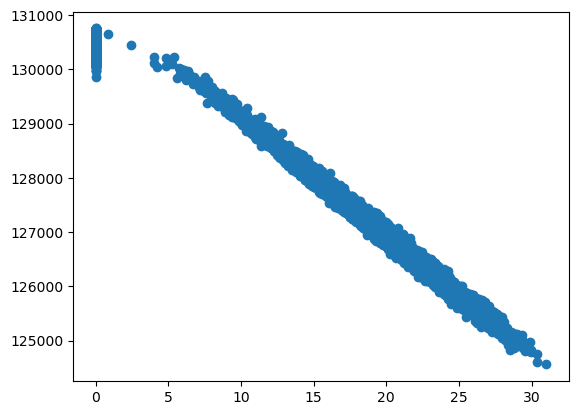

In [29]:
plt.figure()
plt.scatter(np.sum(azav,axis=1),np.amin(dg2_traces,axis=(1,2)))
plt.show()

# Plot average scattered signal normalized to X-ray energy by run rumber

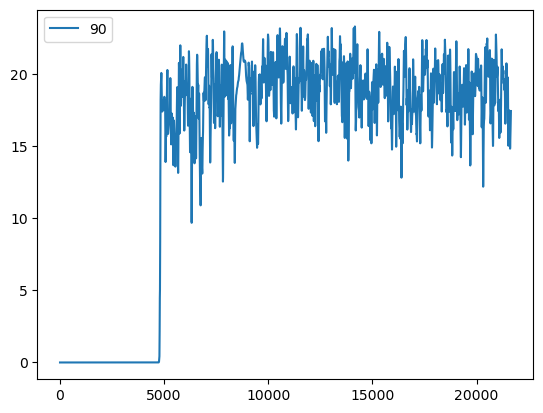

In [30]:
from scipy.ndimage import gaussian_filter1d as gf1
goodIdx = xray_energy>0.0
plt.figure()
for runNumber in runNumbers:
    runNumberMask = run_indicator==runNumber
    plt.plot(np.arange(len(azav))[runNumberMask&goodIdx],
             gf1(np.sum(azav[runNumberMask&goodIdx],axis=-1),10),label=f'{runNumber}')
plt.legend()
plt.show()

# Look at azimuthally integrated scattering signal

(2, 100)


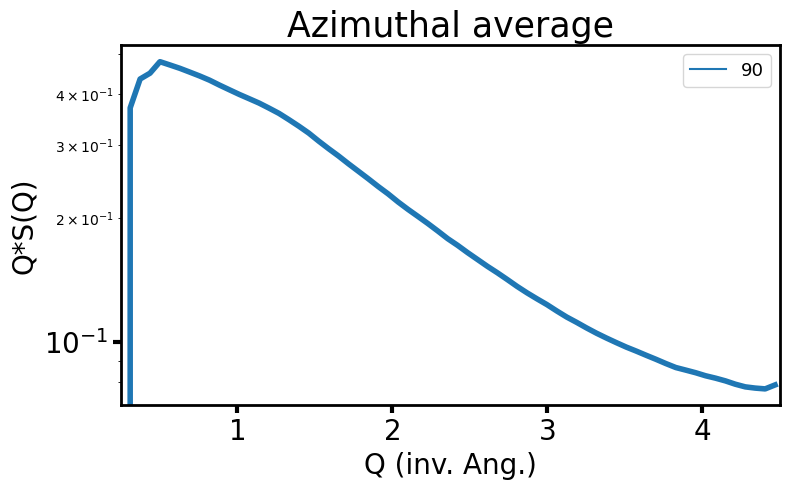

In [31]:
molecule = '2-iodothiophene'
molecule = 'acetylacetone'
molecule = 'C4H6O'
molecule = 'SF6'
molecule = 'NH3'
theory_scattering = np.load(f'/sdf/home/i/igabalsk/Run21/Green-L10060/output/{molecule}_1dscattering.npy')
if molecule=='SF6':
    theory_scattering = np.load(f'/sdf/home/i/igabalsk/Run21/Green-L10060/output/{molecule}_Debye_Total.npy').T
print(theory_scattering.shape)
plt.figure(figsize=(8,5))
maxes = []
for i,runNumber in enumerate(runNumbers):
    avg_azav_laserOff = np.mean(azav_xrays[(run_indicator==runNumber)&(~laserOn)],axis=0)
    normed_azav_laserOff = avg_azav_laserOff/qbin_size
    plt.semilogy(q,normed_azav_laserOff,label=str(runNumber))
    maxes.append(np.max(normed_azav_laserOff))
q_theory,sig_theory = theory_scattering[0],theory_scattering[1]
# sig_theory *= (8+5*6**2+2*8**2)/sig_theory[0]
# plt.plot(q_theory,q_theory*sig_theory/np.mean(sig_theory[(q_theory<2)&(q_theory>1)]),label='Theory')
plt.xlabel('Q (inv. Ang.)')
plt.ylabel('Q*S(Q)')
plt.title('Azimuthal average')
plt.legend(fontsize=13,ncol=4)
plt.xlim(0.25,4.5)
neaten_plot(plt.gcf())

# Correlate DG2 to scattered X-rays in laser off shots

In [32]:
plt.figure()
plt.scatter(scattered_xrays[~laserOn&xrayOn],dg2[~laserOn&xrayOn],alpha=0.1)
plt.plot(np.linspace(scattered_xrays.min(),scattered_xrays.max(),100),
         np.linspace(dg2[~laserOn&xrayOn].min(),dg2[~laserOn&xrayOn].max(),100),color='r',ls='--')
plt.xlabel('Scattered X-rays')
plt.ylabel('DG2')
plt.title(f'Correlation with dg2_sum')

import scipy
rcoeff = scipy.stats.pearsonr(scattered_xrays[~laserOn&xrayOn],dg2[~laserOn&xrayOn])
plt.text(0.1,0.8,f'Pearson r coeff: {rcoeff.statistic:.5f}',
         fontsize=15,fontweight='bold',transform=plt.gca().transAxes,ha='left')
neaten_plot(plt.gcf())
print(rcoeff)

NameError: name 'scattered_xrays' is not defined

<Figure size 640x480 with 0 Axes>

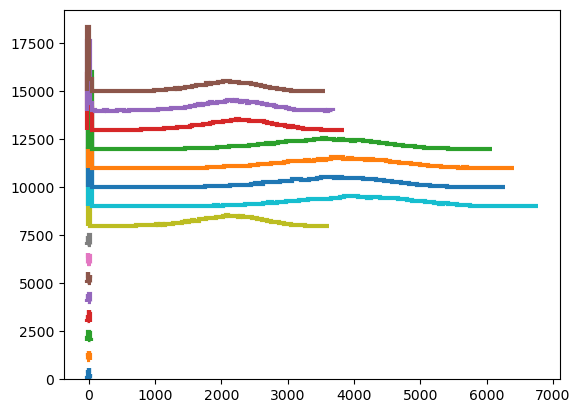

In [9]:
plt.figure()
for i in range(0,16):
    plt.hist(peaks[:,i],bins=100,histtype='step',lw=3,bottom=1000*i)
plt.show()

# Linear regression between each bin in DG2 traces and scattered X-rays

In [10]:
for i in range(16):
    print(np.sum(np.isnan(peaks[:,i])))

935
935
935
935
935
935
935
935
935
935
935
935
935
935
935
935


In [33]:
dg2_traces_flattened = (dg2_traces[:,:,:]).reshape(dg2_traces.shape[0],-1)
# dg2_traces_flattened = np.sum(dg2_traces,axis=-1)
print(dg2_traces_flattened.shape)
peaks_nan = np.isnan(np.sum(peaks,axis=1))

fitIdx = (np.random.uniform(size=laserOn.size)<0.25)&(~laserOn)&(~peaks_nan)
print(np.sum(fitIdx))
testIdx = (~fitIdx)&(~laserOn)&(~peaks_nan)

x, residuals, rank, s = np.linalg.lstsq(dg2_traces_flattened[fitIdx],scattered_xrays[fitIdx],rcond=None)
predicted_xrays = np.matmul(dg2_traces_flattened,x)

# x, residuals, rank, s = np.linalg.lstsq(peaks[fitIdx],scattered_xrays[fitIdx],rcond=None)
# predicted_xrays = np.matmul(peaks,x)

print(predicted_xrays.shape)

(21654, 4096)


NameError: name 'peaks' is not defined

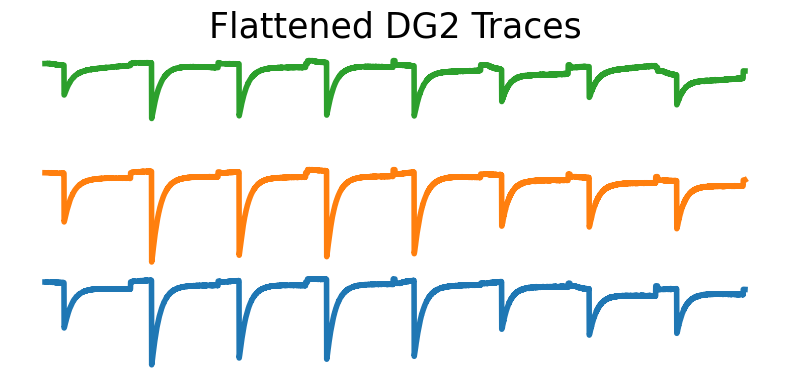

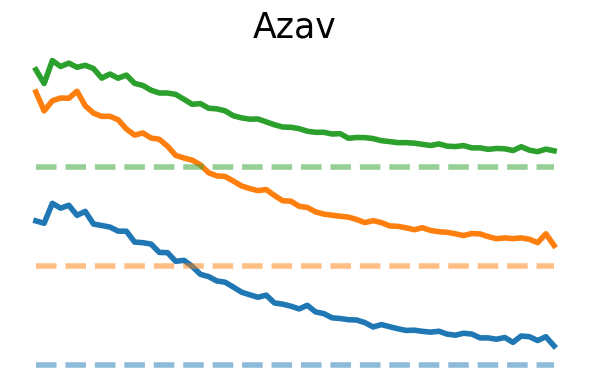

In [27]:
dg2_indices = [5000,10000,20000]

plt.figure(figsize=(8,4))
# plt.subplot(121)
for j, dg2_index in enumerate(dg2_indices):
    plt.plot(dg2_traces_flattened[dg2_index]+7000*j)
    # plt.text(500,trace[-1]+10000*j-1000,f'Shot {dg2_index}',fontsize=15,ha='right',va='top')
plt.xlabel('Index')
plt.ylabel('Diode trace')
plt.title(f'Flattened DG2 Traces')
plt.gca().axis('off')
neaten_plot(plt.gcf())


dg2_indices = [5000,10000,20000]

plt.figure(figsize=(6,4))
# plt.subplot(121)
for j, dg2_index in enumerate(dg2_indices):
    line = plt.plot(q,azav_xrays[dg2_index]/qbin_size+0.5*j)
    plt.plot(q,0*q+0.5*j,color=line[0].get_color(),ls='--',alpha=0.5)
plt.xlabel('Index')
plt.ylabel('Diode trace')
plt.title(f'Azav')
plt.gca().axis('off')
neaten_plot(plt.gcf())

PearsonRResult(statistic=0.9993600125427066, pvalue=0.0)


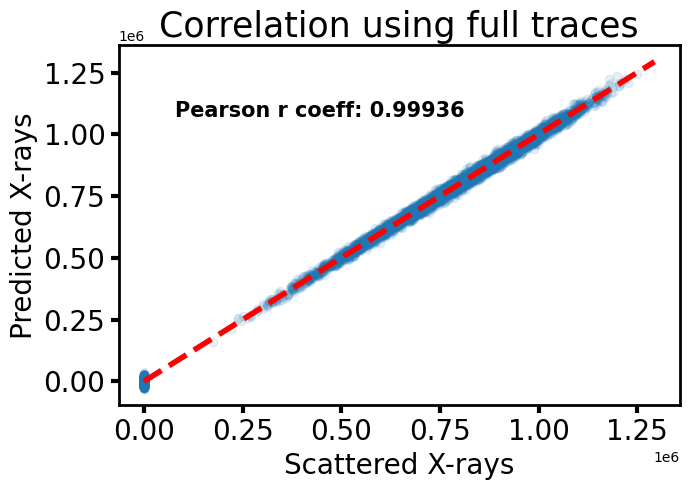

In [30]:
plt.figure(figsize=(7,5))
plt.scatter(scattered_xrays[testIdx],predicted_xrays[testIdx],alpha=0.1)
plt.plot(np.linspace(scattered_xrays.min(),scattered_xrays.max(),100),
         np.linspace(scattered_xrays.min(),scattered_xrays.max(),100),color='r',ls='--')
plt.xlabel('Scattered X-rays')
plt.ylabel('Predicted X-rays')
# plt.title(f'Correlation, traces sampled to length {dg2_traces.shape[-1]}')
plt.title(f'Correlation using full traces')
# plt.title(f'Correlation using refit peaks')

import scipy
rcoeff = scipy.stats.pearsonr(scattered_xrays[testIdx],predicted_xrays[testIdx])
plt.text(0.1,0.8,f'Pearson r coeff: {rcoeff.statistic:.5f}',
         fontsize=15,fontweight='bold',transform=plt.gca().transAxes,ha='left')
neaten_plot(plt.gcf())
print(rcoeff)

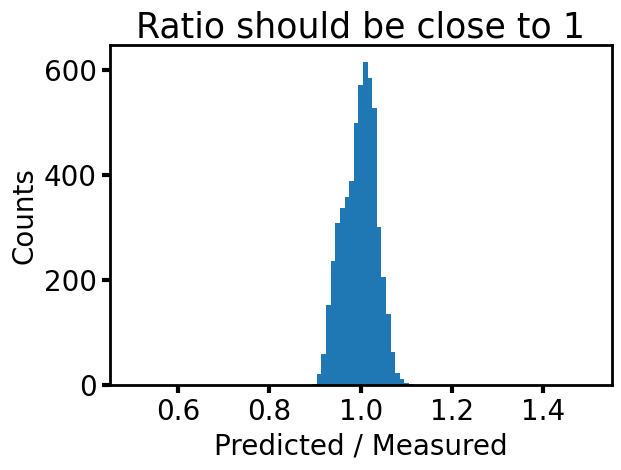

In [24]:
plt.figure()
plt.hist(predicted_xrays[testIdx]/scattered_xrays[testIdx],bins=np.linspace(0.5,1.5,100))
plt.xlabel('Predicted / Measured')
plt.ylabel('Counts')
plt.title('Ratio should be close to 1')
neaten_plot(plt.gcf())

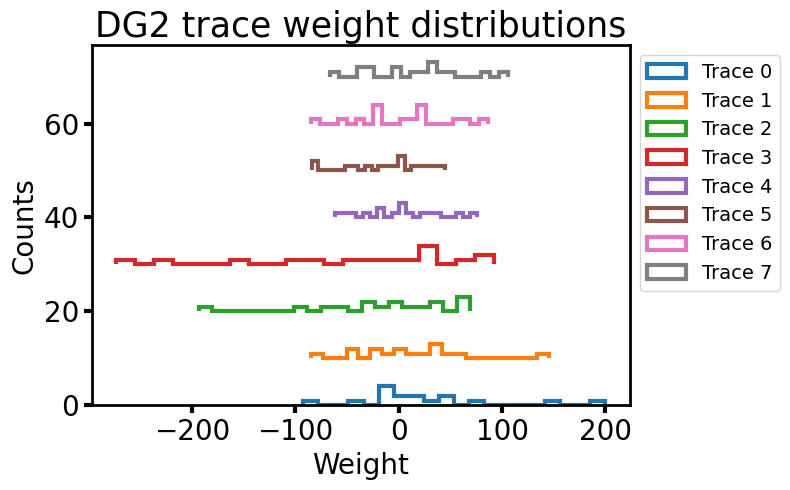

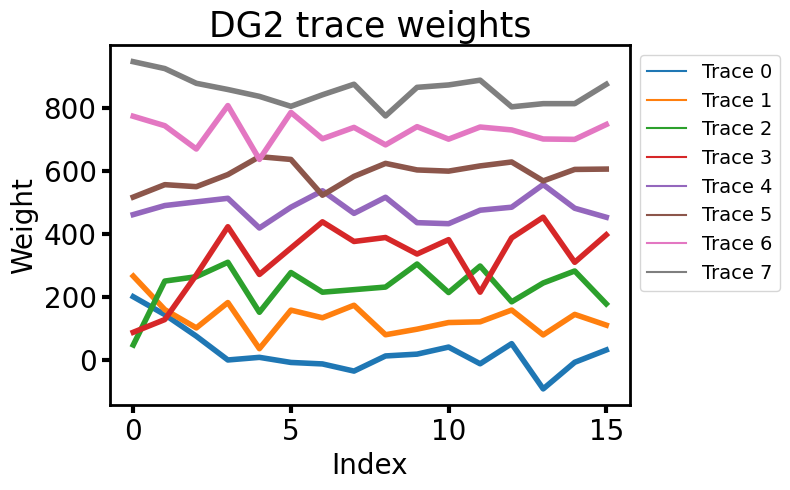

In [50]:
dg2_trace_length = dg2_traces.shape[-1]
plt.figure(figsize=(8,5))
for i in range(8):
    plt.hist(x[dg2_trace_length*i:dg2_trace_length*(i+1)],bins=20,histtype='step',lw=3,label=f'Trace {i}',bottom=10*i)
plt.xlabel('Weight')
plt.ylabel('Counts')
plt.title('DG2 trace weight distributions')
plt.legend(fontsize=14,bbox_to_anchor=(1,1))
neaten_plot(plt.gcf())

plt.figure(figsize=(8,5))
for i in range(8):
    plt.plot(x[dg2_trace_length*i:dg2_trace_length*(i+1)]+120*i,label=f'Trace {i}')
plt.xlabel('Index')
plt.ylabel('Weight')
plt.title('DG2 trace weights')
plt.legend(fontsize=14,bbox_to_anchor=(1,1))
neaten_plot(plt.gcf())
plt.show()

In [14]:
corrected_dg2_traces = (dg2_traces*x.reshape(8,dg2_trace_length))
corrected_dg2_traces.shape

(30073, 8, 32)

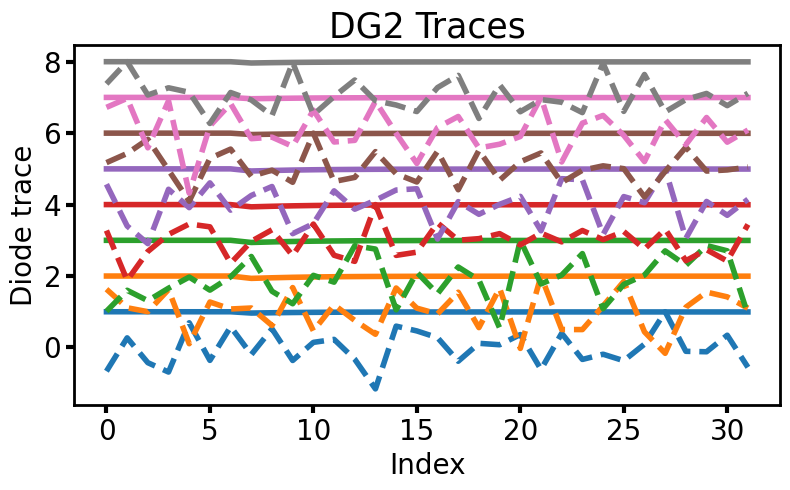

In [15]:
dg2_index = 10001
plt.figure(figsize=(8,5))
for i,trace in enumerate(dg2_traces[dg2_index]):
    line = plt.plot(trace/np.max(trace)+i)
    plt.plot(corrected_dg2_traces[dg2_index,i]/np.max(corrected_dg2_traces[dg2_index,i])+i,ls='--',color=line[0].get_color())
plt.xlabel('Index')
plt.ylabel('Diode trace')
plt.title('DG2 Traces')
# plt.ylim(-1,10)
neaten_plot(plt.gcf())

Text(0, 0.5, 'Predicted X-rays')

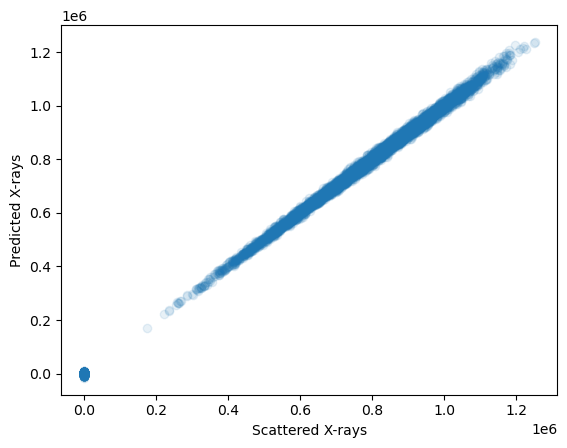

In [149]:
plt.figure()
plt.scatter(scattered_xrays[testIdx],np.sum(corrected_dg2_traces.reshape(dg2_traces.shape[0],-1),axis=-1)[testIdx],alpha=0.1)
# plt.plot(np.linspace(scattered_xrays.min(),scattered_xrays.max(),100),
#          np.linspace(scattered_xrays.min(),scattered_xrays.max(),100),color='r',ls='--')
plt.xlabel('Scattered X-rays')
plt.ylabel('Predicted X-rays')